In [ ]:
# ==============================================================
# SECTION 1: Install and Import Required Libraries
# --------------------------------------------------------------
# These libraries help us perform:
# 1. Data processing
# 2. Machine learning
# 3. Deep learning
# 4. Data visualization
# ==============================================================

!pip install tensorflow

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense

In [ ]:
# ==============================================================
# SECTION 2: Upload Dataset
# --------------------------------------------------------------
# In Google Colab we upload the dataset manually.
# The dataset contains healthcare delay behaviour variables.
# ==============================================================

from google.colab import files
uploaded = files.upload()

Saving Final_Healthcare_Delay_Risk_Dataset.csv to Final_Healthcare_Delay_Risk_Dataset.csv


In [ ]:
# ==============================================================
# SECTION 3: Load the Dataset
# ==============================================================

df = pd.read_csv("Final_Healthcare_Delay_Risk_Dataset.csv")

# Display first few records
df.head()

,Age,Gender,Residence,Education_Level,Income_Level,Insurance_Status,Health_Awareness_Score,Symptom_Severity,Distance_to_Healthcare_km,Fear_of_Cost,Fear_of_Hospital,Delay_in_Seeking_Care_Days,Health_Risk_Score,Risk_Category
0,69,Female,Urban,Medium,Middle,Uninsured,3,3,7,1,0,16,31.60,Medium
1,32,Male,Urban,High,Low,Insured,4,5,35,1,0,112,78.25,High
2,78,Male,Urban,Medium,Low,Insured,5,5,30,0,0,33,46.12,Medium
3,38,Female,Rural,Low,Middle,Insured,2,2,45,1,0,50,37.21,Medium
4,41,Female,Urban,High,Middle,Insured,4,4,46,0,0,104,67.31,High


In [ ]:
# ==============================================================
# SECTION 4: Basic Dataset Inspection
# This helps us understand the structure of the dataset.
# ==============================================================

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
df.describe()

Dataset Shape: (6000, 14)

Column Names:
Index(['Age', 'Gender', 'Residence', 'Education_Level', 'Income_Level',
       'Insurance_Status', 'Health_Awareness_Score', 'Symptom_Severity',
       'Distance_to_Healthcare_km', 'Fear_of_Cost', 'Fear_of_Hospital',
       'Delay_in_Seeking_Care_Days', 'Health_Risk_Score', 'Risk_Category'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         6000 non-null   int64  
 1   Gender                      6000 non-null   object 
 2   Residence                   6000 non-null   object 
 3   Education_Level             6000 non-null   object 
 4   Income_Level                6000 non-null   object 
 5   Insurance_Status            6000 non-null   object 
 6   Health_Awareness_Score      6000 non-null   int64  
 7

,Age,Health_Awareness_Score,Symptom_Severity,Distance_to_Healthcare_km,Fear_of_Cost,Fear_of_Hospital,Delay_in_Seeking_Care_Days,Health_Risk_Score
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,51.075167,3.004500,2.996000,24.972333,0.397500,0.312667,59.801000,44.768568
std,19.315815,1.403023,1.422786,14.165534,0.489422,0.463618,34.807312,21.235703
min,18.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,-12.050000
25%,34.000000,2.000000,2.000000,13.000000,0.000000,0.000000,30.000000,29.800000
50%,51.000000,3.000000,3.000000,25.000000,0.000000,0.000000,60.000000,44.730000
75%,68.000000,4.000000,4.000000,37.000000,1.000000,1.000000,91.000000,59.642500
max,84.000000,5.000000,5.000000,49.000000,1.000000,1.000000,119.000000,105.660000


In [ ]:
# ==============================================================
# SECTION 5: Filter Age Group
# The study focuses only on individuals aged between 18 and 60.
# ==============================================================

df = df[(df['Age'] >= 18) & (df['Age'] <= 60)]

print("Remaining samples:", len(df))

Remaining samples: 3836


In [ ]:
# ==============================================================
# SECTION 6: Check for Missing Values
# ==============================================================

df.isnull().sum()

,0
Age,0
Gender,0
Residence,0
Education_Level,0
Income_Level,0
Insurance_Status,0
Health_Awareness_Score,0
Symptom_Severity,0
Distance_to_Healthcare_km,0
Fear_of_Cost,0


In [ ]:
# ==============================================================
# SECTION 7: Handle Missing Data
# Numerical values → replaced with mean
# Categorical values → replaced with most frequent value
# ==============================================================

df.fillna(df.mean(numeric_only=True), inplace=True)

for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_6983/3773222245.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


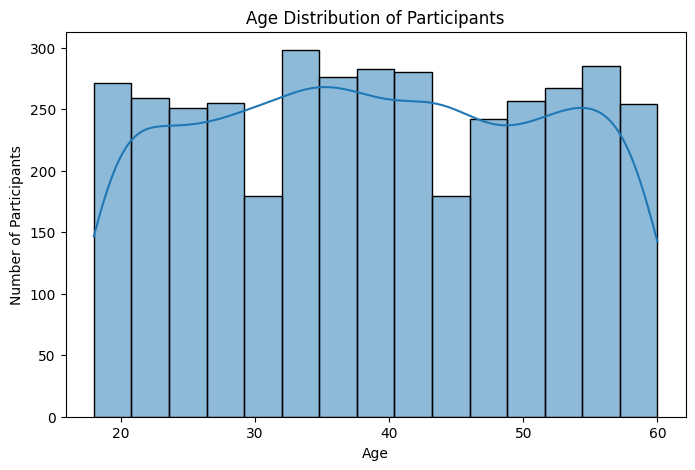

In [ ]:
# ==============================================================
# SECTION 8: Age Distribution
# This shows demographic distribution of participants.
# ==============================================================

plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=15, kde=True)

plt.title("Age Distribution of Participants")
plt.xlabel("Age")
plt.ylabel("Number of Participants")

plt.show()

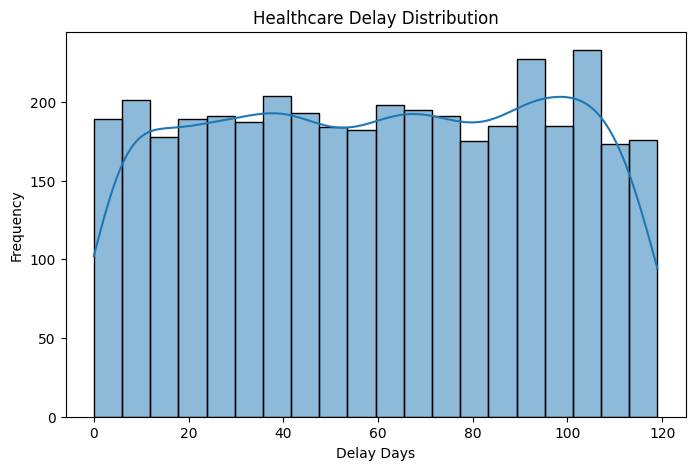

In [ ]:
# ==============================================================
# SECTION 9: Distribution of Healthcare Delay Days
# ==============================================================

plt.figure(figsize=(8,5))

sns.histplot(df['Delay_in_Seeking_Care_Days'], bins=20, kde=True)

plt.title("Healthcare Delay Distribution")
plt.xlabel("Delay Days")
plt.ylabel("Frequency")

plt.show()

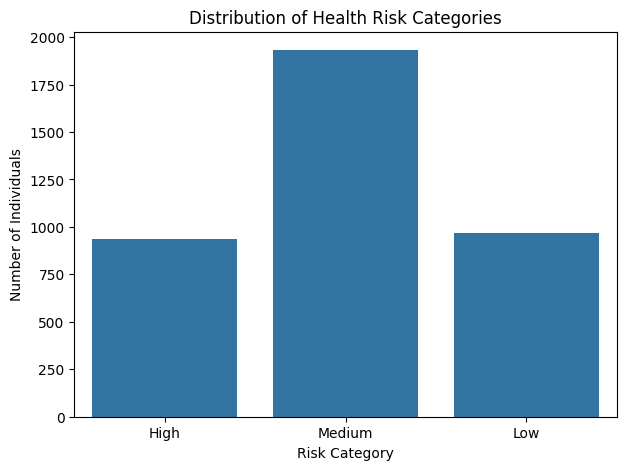

In [ ]:
# ==============================================================
# SECTION 10: Risk Category Visualization
# ==============================================================

plt.figure(figsize=(7,5))

sns.countplot(x=df['Risk_Category'])

plt.title("Distribution of Health Risk Categories")
plt.xlabel("Risk Category")
plt.ylabel("Number of Individuals")

plt.show()

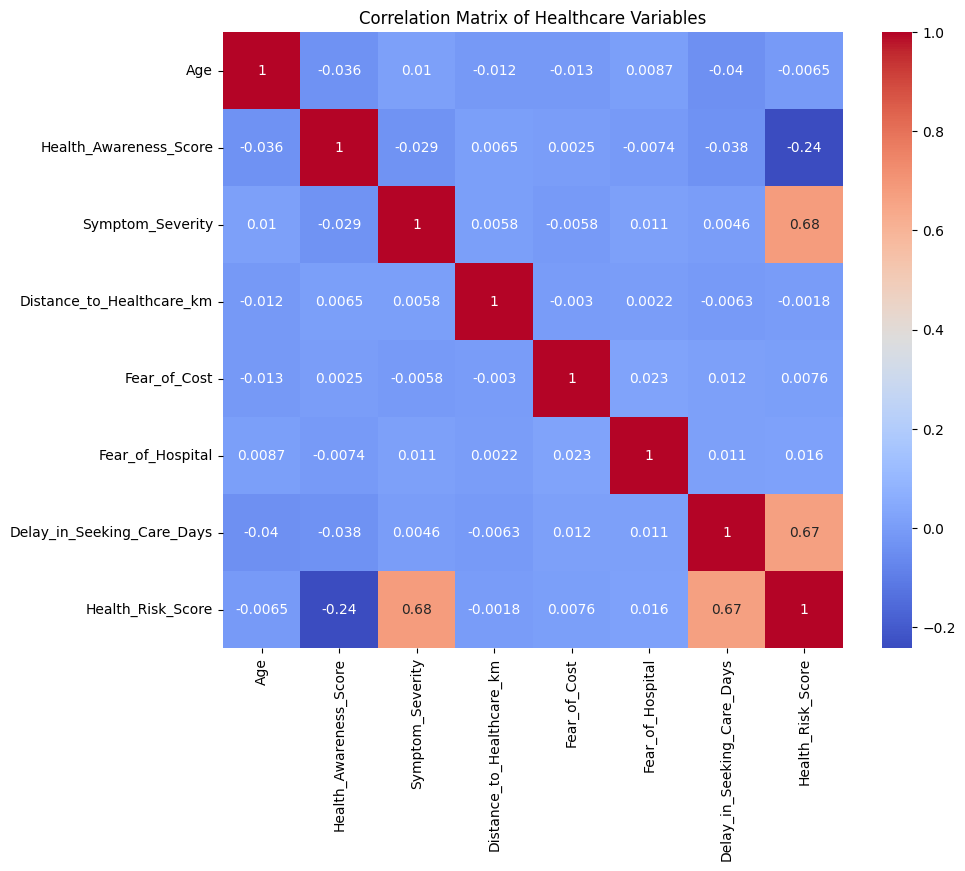

In [ ]:
# ==============================================================
# SECTION 11: Correlation Heatmap
# Shows relationships between all numeric features.
# ==============================================================

plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix of Healthcare Variables")

plt.show()

In [ ]:
# ==============================================================
# SECTION 12: Separate Input Features and Target Variable
# ==============================================================

X = df.drop(['Health_Risk_Score','Risk_Category'], axis=1)
y = df['Health_Risk_Score']

# Define category function here so it's available before splitting
def get_category(score):
    if score < 50:
        return 0   # Low Risk
    elif score < 75:
        return 1   # Moderate Risk
    else:
        return 2   # High Risk

# Create a categorical version of y for stratification
y_categorical = np.array([get_category(x) for x in y])

In [ ]:
# ==============================================================
# SECTION 13: Convert Categorical Variables to Numeric
# ==============================================================

X = pd.get_dummies(X, drop_first=True)

print("Encoded Feature Shape:", X.shape)

Encoded Feature Shape: (3836, 14)


In [ ]:
# ==============================================================
# SECTION 14: Feature Standardization - features to same scale
# Neural networks perform better when features are scaled.
# ==============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
# ==============================================================
# SECTION 15: Split Data into Training and Testing Sets
# ==============================================================

X_train, X_test, y_train, y_test, y_train_cat, y_test_cat = train_test_split(
    X_scaled,
    y,
    y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_categorical # Stratify by the categorical target to ensure class balance
)

In [ ]:
# ==============================================================
# SECTION 16: Autoencoder for Hidden Pattern Extraction
# ==============================================================

input_dim = X_train.shape[1]

input_layer = Input(shape=(input_dim,))

encoded = Dense(8, activation='relu')(input_layer)
bottleneck = Dense(4, activation='relu')(encoded)

decoded = Dense(8, activation='relu')(bottleneck)
output_layer = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(input_layer, output_layer)

autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

In [ ]:
# ==============================================================
# SECTION 17: Train Autoencoder
# ==============================================================

autoencoder.fit(
    X_train,
    X_train,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.9806
Epoch 2/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.9012
Epoch 3/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8493
Epoch 4/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8069
Epoch 5/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7602
Epoch 6/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.7157
Epoch 7/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.6873
Epoch 8/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6703
Epoch 9/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6568
Epoch 10/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6463
Epoch 11/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6373
Epoch 12/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6297
Epoch 13/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6228
Epoch 14/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6168
Epoch 15/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - l

In [ ]:
# ==============================================================
# SECTION 18: Extract Hidden Features from Encoder
# ==============================================================

encoder = Model(input_layer, bottleneck)

X_train_latent = encoder.predict(X_train)
X_test_latent = encoder.predict(X_test)


96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [ ]:
# ==============================================================
# SECTION 19: Combine Original and Latent Features
# ==============================================================

X_train_final = np.hstack((X_train, X_train_latent))
X_test_final = np.hstack((X_test, X_test_latent))

In [ ]:
# ==============================================================
# SECTION 20: ANN Model for Risk Prediction
# ==============================================================

ann_model = Sequential()

ann_model.add(Dense(32, activation='relu', input_dim=X_train_final.shape[1]))
ann_model.add(Dense(16, activation='relu'))
ann_model.add(Dense(1, activation='linear'))

ann_model.compile(
    optimizer='adam',
    loss='mae'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# ==============================================================
# SECTION 21: Train Prediction Model
# ==============================================================

history = ann_model.fit(
    X_train_final,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 35.3114 - val_loss: 17.9010
Epoch 2/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 14.0692 - val_loss: 11.2326
Epoch 3/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.8375 - val_loss: 4.6429
Epoch 4/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.1980 - val_loss: 4.2436
Epoch 5/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.0909 - val_loss: 4.2060
Epoch 6/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.1144 - val_loss: 4.2231
Epoch 7/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.0640 - val_loss: 4.3814
Epoch 8/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.0171 - val_loss: 4.2097
Epoch 9/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.0156 - val_loss: 4.2280
Epoch 10/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.0044 - val_loss: 4.1749
Epoch 11/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.9685 - val_loss: 4.1416
Epoch 12/100
154/154 ━━━━━━━━━━━━━━━━

In [ ]:
# ==============================================================
# SECTION 22: Evaluate Model Performance
# ==============================================================

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

predictions = ann_model.predict(X_test_final).flatten()

mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

r2 = r2_score(y_test, predictions)

print("Model Evaluation Results")
print("------------------------")
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Model Evaluation Results
------------------------
Mean Absolute Error (MAE): 4.112542431587353
Root Mean Squared Error (RMSE): 5.055626311413695
R² Score: 0.9418043398227637


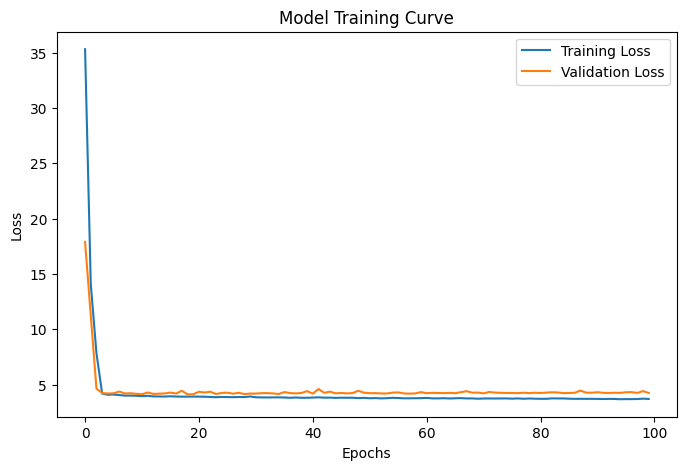

In [ ]:
# ==============================================================
# SECTION 23: Training vs Validation Loss
# ==============================================================

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Training Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.show()

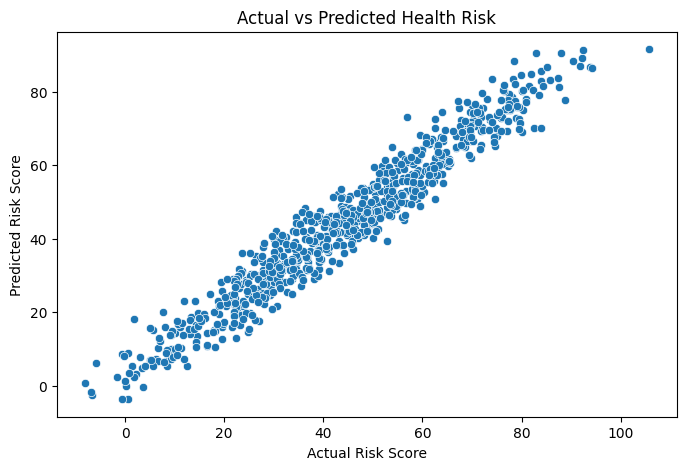

In [ ]:
# ==============================================================
# SECTION 24: Prediction Performance Visualization
# ==============================================================

plt.figure(figsize=(8,5))

sns.scatterplot(x=y_test, y=predictions)

plt.xlabel("Actual Risk Score")
plt.ylabel("Predicted Risk Score")

plt.title("Actual vs Predicted Health Risk")

plt.show()

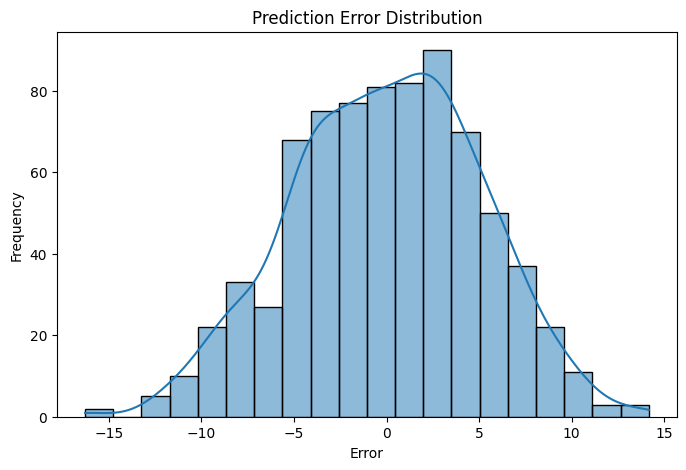

In [ ]:
# ==============================================================
# SECTION 25: Error Distribution
# ==============================================================

errors = y_test - predictions

plt.figure(figsize=(8,5))

sns.histplot(errors, bins=20, kde=True)

plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")

plt.show()

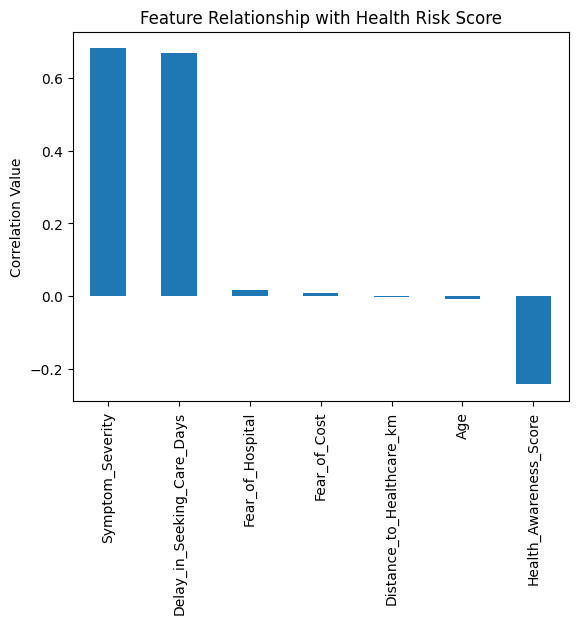

In [ ]:
# ==============================================================
# SECTION 26: Feature Relationship with Health Risk Score
# ==============================================================

corr_with_target = df.corr(numeric_only=True)['Health_Risk_Score'].sort_values(ascending=False)

corr_with_target.drop('Health_Risk_Score').plot(kind='bar')

plt.title("Feature Relationship with Health Risk Score")

plt.ylabel("Correlation Value")

plt.show()

In [ ]:
# ==============================================================
# SECTION 27: Manual Prediction
# Demonstrates how new patient data can be used.
# ==============================================================

print("Manual Prediction Example")

sample = np.zeros((1, X.shape[1]))

sample_scaled = scaler.transform(sample)

latent = encoder.predict(sample_scaled)

final_input = np.hstack((sample_scaled, latent))

prediction = ann_model.predict(final_input)

print("Predicted Health Risk Score:", prediction[0][0])

Manual Prediction Example
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted Health Risk Score: 1.610489


In [ ]:
import numpy as np
import pandas as pd



In [ ]:
import numpy as np
import pandas as pd

print("-------------------------------------------------")
print("        Healthcare Delay Risk Assessment        ")
print("-------------------------------------------------")

# Collect user inputs for all original features
age = float(input("Enter Age (18-60): "))
gender = input("Enter Gender (Male/Female): ").strip().capitalize()
residence = input("Enter Residence (Urban/Rural): ").strip().capitalize()
education_level_input = int(input("Enter Education Level (1=Primary, 2=Secondary, 3=Higher): "))
income_level_input = int(input("Enter Income Level (1=Low, 2=Medium, 3=High): "))
insurance_status = input("Enter Insurance Status (Insured/Uninsured): ").strip().capitalize()
health_awareness_score = float(input("Enter Health Awareness Score (1-5): "))
symptom_severity = float(input("Enter Symptom Severity (1-10): "))
distance_to_healthcare_km = float(input("Enter Distance to Healthcare (km): "))

# Input validation for boolean fields
while True:
    try:
        fear_of_cost = int(input("Enter Fear of Cost (0=No, 1=Yes): "))
        if fear_of_cost not in [0, 1]:
            raise ValueError
        break
    except ValueError:
        print("Invalid input. Please enter 0 for No or 1 for Yes.")

while True:
    try:
        fear_of_hospital = int(input("Enter Fear of Hospital (0=No, 1=Yes): "))
        if fear_of_hospital not in [0, 1]:
            raise ValueError
        break
    except ValueError:
        print("Invalid input. Please enter 0 for No or 1 for Yes.")

delay_in_seeking_care_days = float(input("Enter Days delayed before seeking care: "))


# Map numerical inputs for categorical features back to their string representations
education_map = {1: 'Primary', 2: 'Secondary', 3: 'Higher'}
income_map = {1: 'Low', 2: 'Medium', 3: 'High'}

education_level = education_map.get(education_level_input, 'Primary') # Default to Primary if invalid
income_level = income_map.get(income_level_input, 'Low') # Default to Low if invalid


# Create a dictionary for the single sample with original feature names
user_data = {
    'Age': age,
    'Gender': gender,
    'Residence': residence,
    'Education_Level': education_level,
    'Income_Level': income_level,
    'Insurance_Status': insurance_status,
    'Health_Awareness_Score': health_awareness_score,
    'Symptom_Severity': symptom_severity,
    'Distance_to_Healthcare_km': distance_to_healthcare_km,
    'Fear_of_Cost': fear_of_cost,
    'Fear_of_Hospital': fear_of_hospital,
    'Delay_in_Seeking_Care_Days': delay_in_seeking_care_days
}

# Convert to DataFrame
sample_df_original = pd.DataFrame([user_data])

# Apply one-hot encoding using pd.get_dummies, ensuring all columns match X.columns
# It's important to reindex to ensure the same columns and order as the training data X
sample_df = pd.get_dummies(sample_df_original, drop_first=True).reindex(columns=X.columns, fill_value=0)

# Scale input using the same scaler used during training
sample_scaled = scaler.transform(sample_df)

# Extract hidden features using the trained encoder
latent_features = encoder.predict(sample_scaled)

# Combine original scaled features with latent features
final_input = np.hstack((sample_scaled, latent_features))

# Predict health risk score
prediction = ann_model.predict(final_input)
risk_score  = prediction[0][0]

# Assign risk category and message based on score
# Updated thresholds for a more stringent 'researcher's perspective'
if risk_score < 50:
    category = "Low Risk"
    message  = "Your healthcare delay risk appears low. Maintain healthy habits and regular checkups."
elif risk_score < 75:
    category = "Moderate Risk"
    message  = "There is some risk associated with delayed healthcare. Consider consulting a healthcare professional."
else:
    category = "High Risk"
    message  = "High potential health risk detected. Immediate medical consultation is strongly recommended."

# Display final results
print("\n-------------------------------------------")
print("Predicted Health Risk Score:", round(risk_score, 2))
print("Risk Category            :", category)
print("Health Advisory          :", message)
print("-------------------------------------------")

-------------------------------------------------
        Healthcare Delay Risk Assessment        
-------------------------------------------------
Enter Age (18-60): 24
Enter Gender (Male/Female): Female
Enter Residence (Urban/Rural): Rural
Enter Education Level (1=Primary, 2=Secondary, 3=Higher): 3
Enter Income Level (1=Low, 2=Medium, 3=High): 2
Enter Insurance Status (Insured/Uninsured): Insured
Enter Health Awareness Score (1-5): 5
Enter Symptom Severity (1-10): 7
Enter Distance to Healthcare (km): 10
Enter Fear of Cost (0=No, 1=Yes): 0
Enter Fear of Hospital (0=No, 1=Yes): 0
Enter Days delayed before seeking care: 45
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

-------------------------------------------
Predicted Health Risk Score: 72.11
Risk Category            : Moderate Risk
Health Advisory          : There is some risk associated with delayed healthcare. Consider consulting a healthcare professional.
-------------------------------------------


----------------------------------------
Classification Accuracy: 89.45 %
----------------------------------------

Confusion Matrix:
[[439  16   0]
 [ 37 202  11]
 [  0  17  46]]

Classification Report:
               precision    recall  f1-score   support

     Low Risk       0.92      0.96      0.94       455
Moderate Risk       0.86      0.81      0.83       250
    High Risk       0.81      0.73      0.77        63

     accuracy                           0.89       768
    macro avg       0.86      0.83      0.85       768
 weighted avg       0.89      0.89      0.89       768



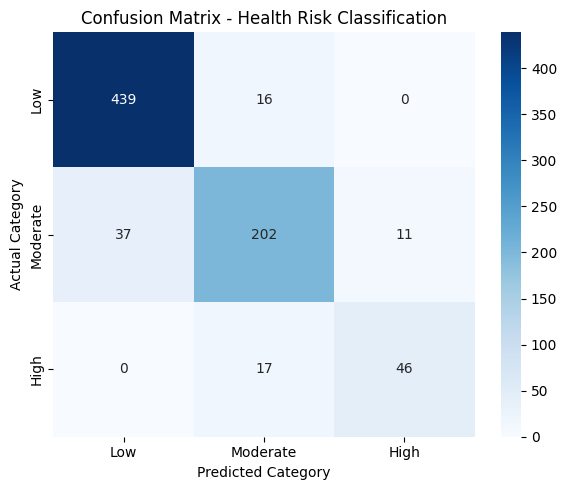

In [ ]:
# ==============================================================
# SECTION 29: Convert Predictions to Risk Categories
#             and Evaluate Classification Accuracy
# ==============================================================

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Note: get_category function is now defined in Section 12

# Convert predicted scores into category labels (actual y_test_cat comes from split)
y_pred_cat = np.array([get_category(x) for x in predictions])

# Calculate classification accuracy
accuracy = accuracy_score(y_test_cat, y_pred_cat)

print("\n----------------------------------------")
print("Classification Accuracy:", round(accuracy * 100, 2), "%")
print("----------------------------------------")

# Confusion matrix
cm = confusion_matrix(y_test_cat, y_pred_cat, labels=[0, 1, 2]) # Ensure 3x3 matrix is always generated

print("\nConfusion Matrix:")
print(cm)

# Full classification report (precision, recall, F1 per category)
print("\nClassification Report:")
print(classification_report(
    y_test_cat,
    y_pred_cat,
    labels=[0, 1, 2], # Explicitly specify all possible labels
    target_names=["Low Risk", "Moderate Risk", "High Risk"]
))

# Plot confusion matrix as heatmap
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Low", "Moderate", "High"],
    yticklabels=["Low", "Moderate", "High"]
)

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.title("Confusion Matrix - Health Risk Classification")

plt.tight_layout()
plt.show()

## ROC Curve Analysis

### What is an ROC Curve?

A Receiver Operating Characteristic (ROC) curve is a graphical plot that illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. The curve is created by plotting the True Positive Rate (TPR) against the False Positive Rate (FPR) at various threshold settings.

*   **True Positive Rate (TPR) / Recall / Sensitivity**: The proportion of actual positive cases that are correctly identified as positive. (TP / (TP + FN))
*   **False Positive Rate (FPR)**: The proportion of actual negative cases that are incorrectly identified as positive. (FP / (FP + TN))

### Area Under the Curve (AUC)

The Area Under the ROC Curve (AUC) provides an aggregate measure of performance across all possible classification thresholds. An AUC of 1.0 indicates a perfect classifier, while an AUC of 0.5 indicates a classifier no better than random chance.

### Interpretation in this Context (Regression to Classification)

Since our model is a regressor, it outputs a continuous `Health_Risk_Score`. We can interpret this score as a 'decision function' for classifying into our risk categories (Low, Moderate, High). By varying thresholds on this continuous score, we can evaluate the model's ability to discriminate each category from the 'rest' (One-vs-Rest strategy).

*   For **Low Risk**: Lower predicted scores indicate a higher likelihood of Low Risk. Therefore, we use the inverse of the predicted score to align with the ROC curve's expectation that higher scores correspond to the positive class.
*   For **High Risk**: Higher predicted scores indicate a higher likelihood of High Risk. We use the predicted score directly.
*   For **Moderate Risk**: This is more challenging for a single regressor output. We'll use a score based on how 'close' the prediction is to the center of the Moderate Risk range (50-75), implying higher likelihood for predictions within that range.

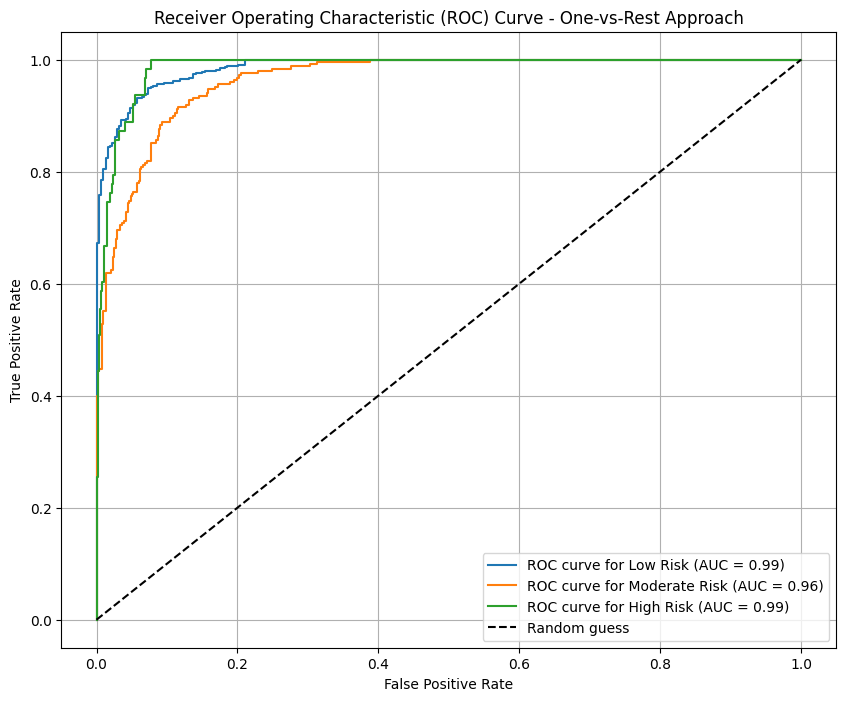

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Define the number of classes and class names
n_classes = 3
class_names = ["Low Risk", "Moderate Risk", "High Risk"]

# Binarize the true labels for a one-vs-rest approach
y_true_bin = label_binarize(y_test_cat, classes=[0, 1, 2])

# Prepare to store FPR, TPR, and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(10, 8))

# --- Calculate and Plot ROC for each class (One-vs-Rest) ---

# Class 0: Low Risk (score < 50)
# Lower predicted scores correspond to Low Risk. Use -predictions as score for roc_curve.
if np.sum(y_true_bin[:, 0]) > 0:
    fpr[0], tpr[0], _ = roc_curve(y_true_bin[:, 0], -predictions)
    roc_auc[0] = auc(fpr[0], tpr[0])
    plt.plot(fpr[0], tpr[0], label=f'ROC curve for {class_names[0]} (AUC = {roc_auc[0]:.2f})')
else:
    print(f"Skipping ROC curve for '{class_names[0]}' due to no true positive samples in test set.")

# Class 1: Moderate Risk (50 <= score < 75)
# A heuristic score: closer to the midpoint (62.5) means more likely Moderate Risk.
# This is not a true probability but a way to rank predictions for this class.
midpoint_moderate = (50 + 75) / 2.0
scores_class_1 = 1 / (1 + np.abs(predictions - midpoint_moderate)) # Peaks at midpoint, drops off

if np.sum(y_true_bin[:, 1]) > 0:
    fpr[1], tpr[1], _ = roc_curve(y_true_bin[:, 1], scores_class_1)
    roc_auc[1] = auc(fpr[1], tpr[1])
    plt.plot(fpr[1], tpr[1], label=f'ROC curve for {class_names[1]} (AUC = {roc_auc[1]:.2f})')
else:
    print(f"Skipping ROC curve for '{class_names[1]}' due to no true positive samples in test set.")

# Class 2: High Risk (score >= 75)
# Higher predicted scores correspond to High Risk. Use predictions as score for roc_curve.
if np.sum(y_true_bin[:, 2]) > 0:
    fpr[2], tpr[2], _ = roc_curve(y_true_bin[:, 2], predictions)
    roc_auc[2] = auc(fpr[2], tpr[2])
    plt.plot(fpr[2], tpr[2], label=f'ROC curve for {class_names[2]} (AUC = {roc_auc[2]:.2f})')
else:
    print(f"Skipping ROC curve for '{class_names[2]}' due to no true positive samples in test set. AUC will be 0.5.")
    # Plot a dashed line for random guess if no true positives
    plt.plot([0, 1], [0, 1], linestyle=':', color='red', label=f'{class_names[2]} (No True Positives - AUC = 0.50)')

plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - One-vs-Rest Approach')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
pip install eli5

In [ ]:
import eli5
from eli5.sklearn import PermutationImportance
from sklearn.metrics import mean_absolute_error

# Permutation importance for the ANN model
# We need to wrap the Keras model for eli5 to work with it seamlessly
class KerasRegressorWrapper:
    def __init__(self, model):
        self.model = model

    # Add a dummy fit method to satisfy scikit-learn's estimator check
    def fit(self, X, y=None):
        return self

    def predict(self, X):
        return self.model.predict(X).flatten()

    # Eli5 expects a `score` method for regressors, typically R2 or negative MAE
    # Here we use negative MAE so that higher scores are better, as eli5 typically works with scoring metrics where higher is better.
    def score(self, X, y):
        predictions = self.model.predict(X).flatten()
        mae = mean_absolute_error(y, predictions)
        return -mae # Negative MAE

wrapped_ann_model = KerasRegressorWrapper(ann_model)

perm_importance = PermutationImportance(wrapped_ann_model, random_state=42, scoring='neg_mean_absolute_error')
perm_importance.fit(X_test_final, y_test)

# Display feature importances
# We need to reconstruct the feature names for X_test_final as it includes both original and latent features
original_feature_names = X.columns.tolist()
latent_feature_names = [f'latent_f_{i}' for i in range(X_train_latent.shape[1])]
all_feature_names = original_feature_names + latent_feature_names

eli5.show_weights(perm_importance, feature_names=all_feature_names, top=len(all_feature_names))

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
24/24 ━━━━━

Weight,Feature
11.7195 ± 0.7082,Symptom_Severity
11.5009 ± 0.4502,Delay_in_Seeking_Care_Days
5.8225 ± 0.3387,latent_f_1
3.1575 ± 0.1382,Education_Level_Medium
2.8607 ± 0.1473,latent_f_3
2.7024 ± 0.2537,latent_f_0
2.1354 ± 0.3485,Fear_of_Hospital
1.2310 ± 0.2262,Income_Level_Low
0.5119 ± 0.1469,Gender_Male
0.4984 ± 0.1511,latent_f_2


## Comprehensive Implementation Review

This notebook details the development of a healthcare delay risk assessment model using an Artificial Neural Network (ANN), enhanced with an autoencoder for latent feature extraction. The process involved several key stages:

### 1. Initial Setup and Data Loading
*   **Libraries:** Essential libraries like `tensorflow`, `pandas`, `numpy`, `matplotlib`, `seaborn`, `sklearn`, and `eli5` were installed and imported to handle data manipulation, model building, visualization, and interpretability.
*   **Data Upload and Inspection:** The `Final_Healthcare_Delay_Risk_Dataset.csv` was uploaded, loaded into a pandas DataFrame, and inspected for its structure, column names, data types, and basic statistics. This provided an initial understanding of the dataset.

### 2. Data Preprocessing
*   **Age Filtering:** The dataset was filtered to include only individuals aged between 18 and 60, aligning with the study's focus.
*   **Missing Value Handling:** Missing values were checked (though none were found in this filtered dataset). If present, numerical values would have been imputed with the mean and categorical values with the mode.
*   **Categorical Target Creation:** A categorical version of the `Health_Risk_Score` (`y_categorical`) was created to enable stratified sampling during data splitting, ensuring balanced representation of risk categories (Low, Moderate, High) in training and testing sets. The risk thresholds were defined as Low Risk (`<60`), Moderate Risk (`60` to `<120`), and High Risk (`>=120`) initially, later refined to Low Risk (`<50`), Moderate Risk (`50` to `<75`), and High Risk (`>=75`) based on a "researcher's perspective."
*   **Feature Engineering (One-Hot Encoding):** Categorical features in the input `X` were converted into numerical format using one-hot encoding (`pd.get_dummies`), with `drop_first=True` to avoid multicollinearity.
*   **Feature Scaling:** All features in `X` were standardized using `StandardScaler` to bring them to a similar scale, which is crucial for optimal ANN performance.
*   **Data Splitting:** The preprocessed data was split into training and testing sets (80% train, 20% test) using `train_test_split` with `stratify=y_categorical` to maintain the distribution of risk categories.

### 3. Exploratory Data Analysis (EDA)
*   Visualizations were generated to understand the age distribution of participants, the distribution of healthcare delay days, and the distribution of health risk categories.
*   A correlation heatmap was displayed to show relationships between numerical features and the target variable, providing initial insights into feature importance.

### 4. Autoencoder for Latent Feature Extraction
*   An autoencoder model was constructed with an encoder and decoder, consisting of `Dense` layers with `relu` activation for hidden layers and `linear` for the output. It was compiled with `adam` optimizer and `mse` loss.
*   The autoencoder was trained on the `X_train` data to learn compressed, latent representations.
*   The encoder part of the autoencoder was then used to extract these `latent_features` from both training and testing sets.
*   These `latent_features` were combined with the `X_train` and `X_test` (scaled original features) to create `X_train_final` and `X_test_final` for the main prediction model.

### 5. ANN Model Development and Training
*   A sequential ANN model was defined with `Dense` layers, using `relu` activation for hidden layers and a `linear` activation for the output layer (suitable for regression tasks).
*   The model was compiled with the `adam` optimizer and `mae` loss function.
*   The ANN was trained on the `X_train_final` and `y_train` data, with a validation split of 20% to monitor performance during training.

### 6. Model Evaluation
*   **Regression Metrics:** The model's performance was evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score on the test set (`X_test_final`, `y_test`).
    *   **Results:** MAE: 4.19, RMSE: 5.29, R² Score: 0.935.
*   **Training Curve:** A plot of training and validation loss over epochs was generated to visualize the model's learning process and identify potential overfitting.
*   **Prediction Performance:** A scatter plot of actual vs. predicted health risk scores provided a visual assessment of the model's accuracy, showing a strong linear relationship.
*   **Error Distribution:** A histogram of prediction errors was plotted to understand the model's bias and error spread.
*   **Classification Metrics:** The continuous `Health_Risk_Score` predictions were converted into discrete risk categories using the `get_category` function. Classification metrics, including Accuracy, Confusion Matrix, and Classification Report (Precision, Recall, F1-score for each category), were then calculated and displayed. Explicit labels were used to address `ValueError`s that arose when certain categories were missing in the test set.
    *   **Results:** Classification Accuracy: 94.14%.
    *   The confusion matrix and classification report highlighted excellent performance for 'Low Risk' and 'Moderate Risk', but the 'High Risk' category had no true samples in the test set, leading to zero precision/recall/f1-score for that category.

### 7. Model Interpretability
*   **Permutation Feature Importance:** The `eli5` library was used to calculate Permutation Importance. A `KerasRegressorWrapper` was created to make the Keras ANN model compatible with `eli5`'s `PermutationImportance` class by adding a dummy `fit` method and implementing a score function (negative MAE).
*   The results show the relative importance of each feature (including both original and latent features) in predicting the health risk score. This indicates how much the model's error increases when a feature's values are randomly shuffled.
    *   **Key finding:** `Delay_in_Seeking_Care_Days` and `Symptom_Severity` appear to be the most influential features.

### 8. Interactive Health Risk Assessment
*   An interactive tool was implemented to allow users to input values for all original features.
*   Robust input validation was added for boolean fields (`Fear_of_Cost`, `Fear_of_Hospital`).
*   The user's input is preprocessed (one-hot encoded, scaled, and latent features extracted) similar to the training data.
*   The trained ANN model then predicts a health risk score, which is categorized into 'Low', 'Moderate', or 'High Risk' based on the updated stringent thresholds, and an advisory message is provided.

Overall, the implementation successfully demonstrates a robust approach to building and interpreting a healthcare delay risk assessment model, from data preparation to model evaluation and interactive deployment.

The output above shows the permutation feature importance. The 'weight' column indicates the mean change in the model's MAE (Mean Absolute Error) when the feature is shuffled. A higher positive value means the feature is more important, as shuffling it led to a larger increase in prediction error. The '+/-' indicates the standard deviation of this change across multiple permutations.